# Eksploracyjna analiza danych 

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

## Wczytanie i sprawdzenie danych 

In [43]:
df = pd.read_csv("data/weather_history_for_eda.csv", parse_dates=["date"])
df.head()

,date,avg_temp,min_temp,max_temp,precipitation_total_mm,max_snow_dept_mm,wind_direction,avg_wind_speed_km/h,max_wind_speed,pressure,sunshine_total_min,station_name
0,2020-01-01,-1.7,-4.6,0.1,NaN,NaN,NaN,6.8,18.5,1033.2,NaN,Zakopane
1,2020-01-02,-1.7,-5.4,5.6,NaN,NaN,NaN,5.6,13.0,1031.1,NaN,Zakopane
2,2020-01-03,-1.4,-6.0,5.8,NaN,NaN,NaN,4.6,22.2,1025.6,NaN,Zakopane
3,2020-01-04,0.7,-2.4,4.5,NaN,NaN,NaN,13.2,33.3,1020.9,NaN,Zakopane
4,2020-01-05,-4.1,-5.1,-2.5,NaN,NaN,NaN,8.9,31.5,1029.3,NaN,Zakopane


## Wstępna analiza danych 

### Sprawdzenie typów dancyh 

In [44]:
df.dtypes

date                      datetime64[us]
avg_temp                         float64
min_temp                         float64
max_temp                         float64
precipitation_total_mm           float64
max_snow_dept_mm                 float64
wind_direction                   float64
avg_wind_speed_km/h              float64
max_wind_speed                   float64
pressure                         float64
sunshine_total_min               float64
station_name                         str
dtype: object

**Wnioski**
- Wszystkie kolumny mają oczekiwane wartości typów

### Rozmiar datafram'u

In [45]:
df.shape

(5484, 12)

### Wartości brakujące

In [5]:
df.isna().sum()

date                         0
avg_temp                     0
min_temp                    26
max_temp                    26
precipitation_total_mm    1760
max_snow_dept_mm          5421
wind_direction            5484
avg_wind_speed_km/h          0
max_wind_speed            1850
pressure                   379
sunshine_total_min        5484
station_name                 0
dtype: int64

In [6]:
df.groupby(["station_name",df["date"].dt.year])["precipitation_total_mm"].count()  # ilość danych opadów w każdym roku w poszczególnych stacjach

station_name     date
Kasprowy Wierch  2020      0
                 2021    364
                 2022    364
                 2023    365
                 2024    353
                 2025      1
Poprad/Tatry     2020    366
                 2021      6
                 2022    253
                 2023    365
                 2024    348
                 2025      1
Zakopane         2020      0
                 2021      0
                 2022    219
                 2023    365
                 2024    353
                 2025      1
Name: precipitation_total_mm, dtype: int64

### Usunięcie kolumn z wartościami brakującymi 

In [7]:
columns_to_drop = ["max_snow_dept_mm", "wind_direction", "max_wind_speed", "sunsine_total_min"]

df = df.drop(columns=columns_to_drop, errors="ignore")
df

,date,avg_temp,min_temp,max_temp,precipitation_total_mm,avg_wind_speed_km/h,pressure,sunshine_total_min,station_name
0,2020-01-01,-1.7,-4.6,0.1,NaN,6.8,1033.2,NaN,Zakopane
1,2020-01-02,-1.7,-5.4,5.6,NaN,5.6,1031.1,NaN,Zakopane
2,2020-01-03,-1.4,-6.0,5.8,NaN,4.6,1025.6,NaN,Zakopane
3,2020-01-04,0.7,-2.4,4.5,NaN,13.2,1020.9,NaN,Zakopane
4,2020-01-05,-4.1,-5.1,-2.5,NaN,8.9,1029.3,NaN,Zakopane
...,...,...,...,...,...,...,...,...,...
5479,2024-12-28,1.2,-4.1,9.1,0.0,6.8,1027.8,NaN,Poprad/Tatry
5480,2024-12-29,-1.0,-5.9,6.5,0.0,3.7,1025.2,NaN,Poprad/Tatry
5481,2024-12-30,-5.8,-7.6,-2.7,0.0,3.8,1026.4,NaN,Poprad/Tatry
5482,2024-12-31,-6.3,-7.4,-5.0,0.0,3.3,1027.8,NaN,Poprad/Tatry


### Statystyki opisowe 

In [8]:
df.describe()

,date,avg_temp,min_temp,max_temp,precipitation_total_mm,avg_wind_speed_km/h,pressure,sunshine_total_min
count,5484,5484.000000,5458.000000,5458.000000,3724.000000,5484.000000,5105.000000,0.0
mean,2022-07-02 12:00:00,5.355252,1.379553,9.562349,3.132438,13.218709,1017.201175,NaN
min,2020-01-01 00:00:00,-23.100000,-24.600000,-21.500000,0.000000,1.600000,987.500000,NaN
25%,2021-04-01 18:00:00,-1.000000,-4.100000,2.100000,0.000000,5.700000,1012.200000,NaN
50%,2022-07-02 12:00:00,5.200000,1.300000,9.200000,0.600000,10.000000,1017.700000,NaN
75%,2023-10-02 06:00:00,12.000000,7.400000,16.900000,4.000000,17.500000,1022.200000,NaN
max,2025-01-01 00:00:00,24.700000,19.300000,33.100000,42.700000,62.200000,1045.700000,NaN
std,NaN,8.325039,7.685389,9.502985,5.312670,9.971131,8.104874,NaN


## Analiza pojedynczych cech 

In [9]:
df[df["date"].dt.year.isin([2022, 2023, 2024, 2025])]

,date,avg_temp,min_temp,max_temp,precipitation_total_mm,avg_wind_speed_km/h,pressure,sunshine_total_min,station_name
731,2022-01-01,6.1,4.8,7.5,NaN,8.1,1021.9,NaN,Zakopane
732,2022-01-02,4.6,0.5,10.5,NaN,4.8,1021.7,NaN,Zakopane
733,2022-01-03,5.0,2.6,8.9,NaN,12.3,1013.2,NaN,Zakopane
734,2022-01-04,6.7,2.6,10.5,NaN,10.4,1004.6,NaN,Zakopane
735,2022-01-05,4.0,-1.4,9.8,NaN,8.5,1001.2,NaN,Zakopane
...,...,...,...,...,...,...,...,...,...
5479,2024-12-28,1.2,-4.1,9.1,0.0,6.8,1027.8,NaN,Poprad/Tatry
5480,2024-12-29,-1.0,-5.9,6.5,0.0,3.7,1025.2,NaN,Poprad/Tatry
5481,2024-12-30,-5.8,-7.6,-2.7,0.0,3.8,1026.4,NaN,Poprad/Tatry
5482,2024-12-31,-6.3,-7.4,-5.0,0.0,3.3,1027.8,NaN,Poprad/Tatry


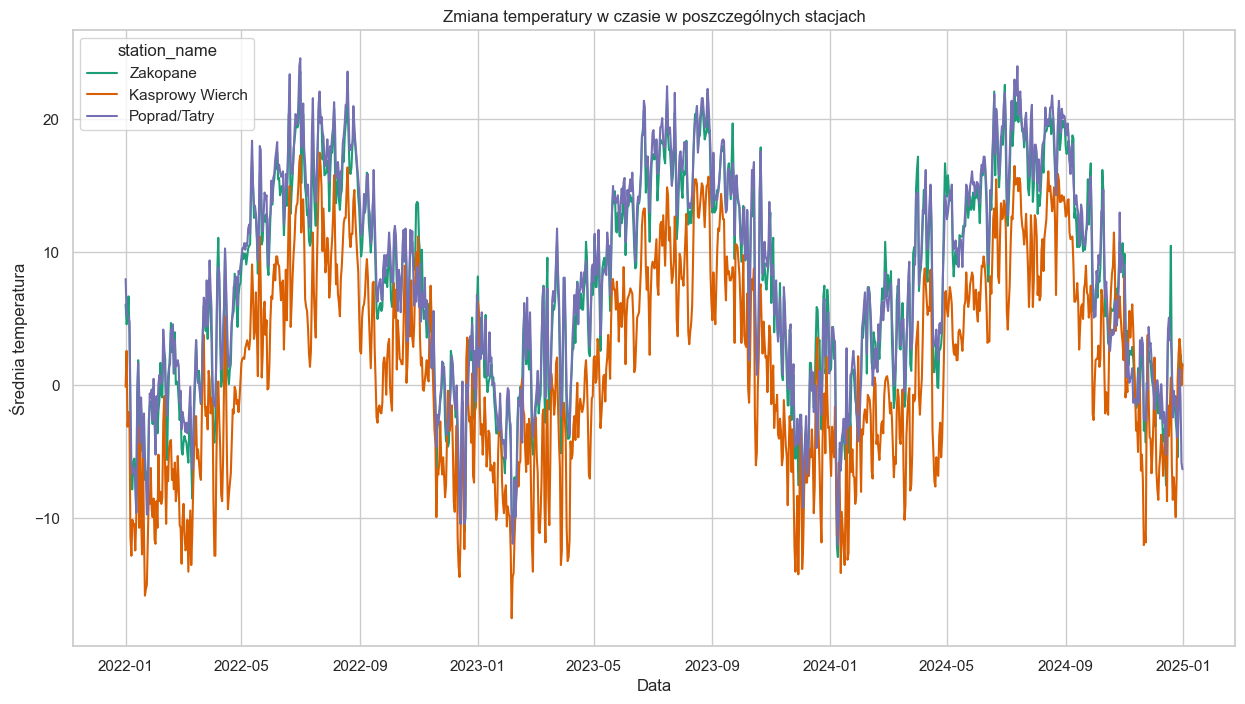

In [10]:
sns.lineplot(df[df["date"].dt.year.isin([2022, 2023, 2024])], x="date", y="avg_temp", hue="station_name", palette="Dark2")
plt.title("Zmiana temperatury w czasie w poszczególnych stacjach")
plt.xlabel("Data", fontsize=12)
plt.ylabel("Średnia temperatura", fontsize=12);

**Wnioski**
- Wyraźna sezonowość – wysokie temperatury latem, niskie zimą.
- Na Kasprowym Wierchu występuje najniższa temperatura i największe wachania w czasie
- Poprad i Zakopane mają podobny przebieg temperatur, jednak różnią się amplitudą (zakresem zmian).
- Widoczne krótkotrwałe anomalie (nagłe wzrosty/spadki).

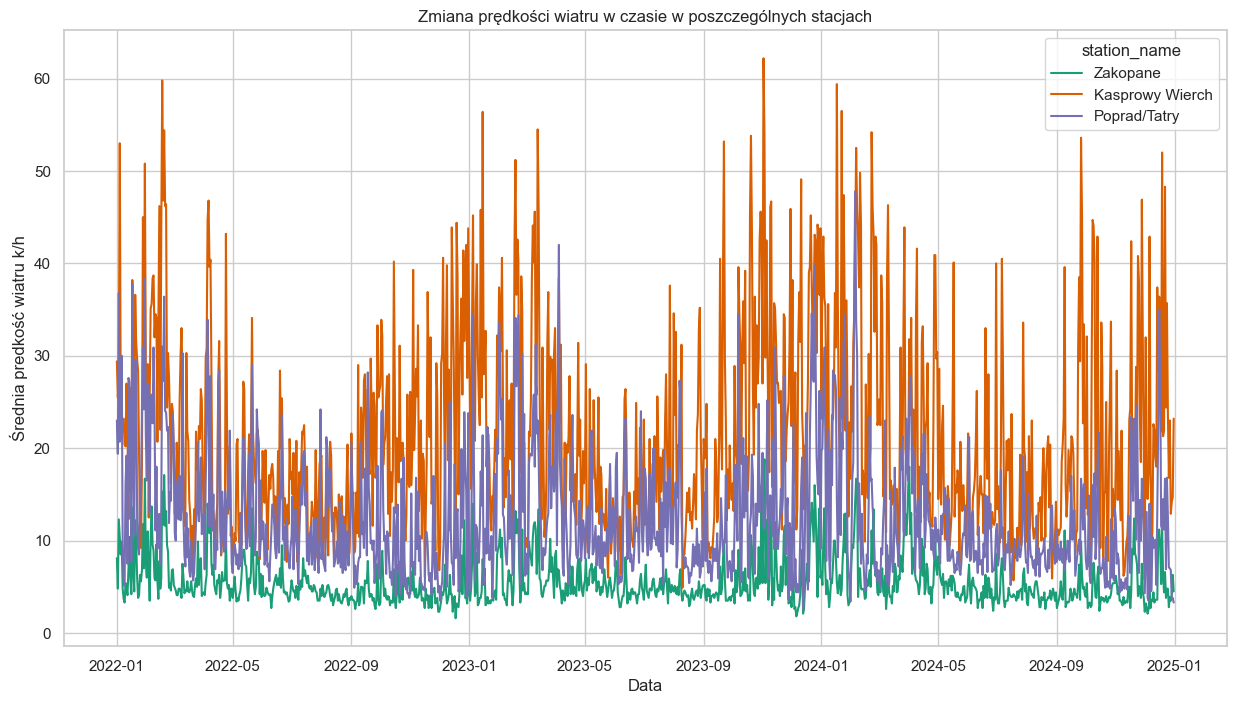

In [11]:
sns.lineplot(df[df["date"].dt.year.isin([2022, 2023, 2024])], x="date", y="avg_wind_speed_km/h", hue="station_name", palette="Dark2")
plt.title("Zmiana prędkości wiatru w czasie w poszczególnych stacjach")
plt.xlabel("Data", fontsize=12)
plt.ylabel("Średnia predkość wiatru k/h", fontsize=12);

**Wnioski**
- Kaspowy Wierch ma nawyższe i najbardziej zmienne prędkości wiatru.
- Na pozostałych stacjach wiatr jest słabszy i bardziej stabilny.
- Silniejszy wiatr występuje częściej przy niższych temperaturach.

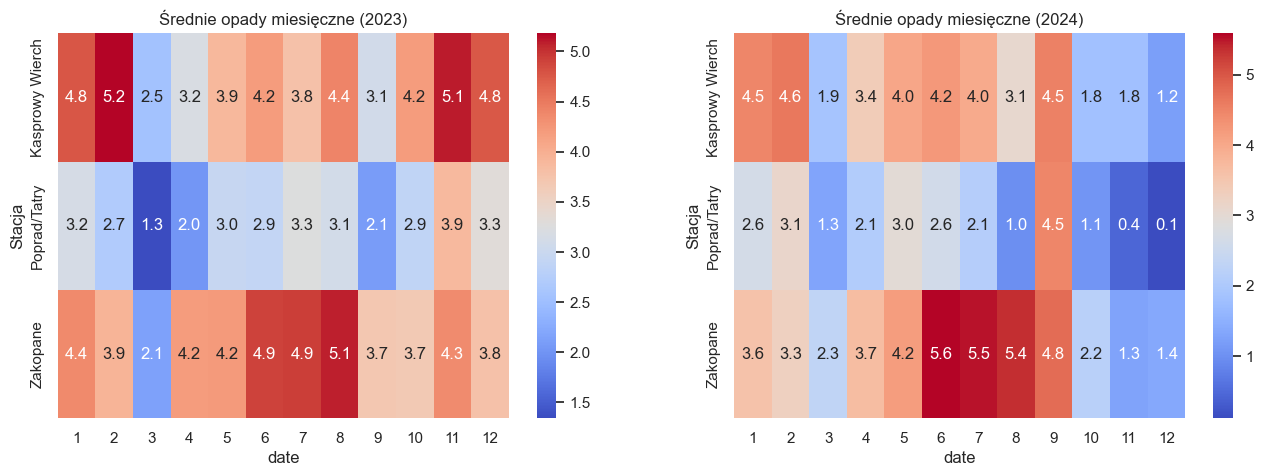

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5)) 

pivot_2023 = df[df["date"].dt.year == 2023].pivot_table(
    values="precipitation_total_mm",
    index="station_name",
    columns=df["date"].dt.month,
    aggfunc="mean"
)
sns.heatmap(pivot_2023, cmap="coolwarm", annot=True, fmt=".1f", ax=axes[0])
axes[0].set_title("Średnie opady miesięczne (2023)")
axes[0].set_ylabel("Stacja")

pivot_2024 = df[df["date"].dt.year == 2024].pivot_table(
    values="precipitation_total_mm",
    index="station_name",
    columns=df["date"].dt.month,
    aggfunc="mean"
)
sns.heatmap(pivot_2024, cmap="coolwarm", annot=True, fmt=".1f", ax=axes[1])
axes[1].set_title("Średnie opady miesięczne (2024)")
axes[1].set_ylabel("Stacja");

**Wnioski**
- Zakopane i Kasprowy Wierch notują wyższe opady niż Poprad, co wskazuje na wpływ terenów górskich.
- Widoczna jest sezonowość opadów – najwyższe latem (VI–VIII), najniższe zimą i wczesną wiosną.
- Stacja Poprad/Tatry notuje najniższe wartości opadów spośród trzech analizowanych lokalizacji, co może wynikać z jej specyficznego położenia geograficznego (cień opadowy).
- Przesunięcie szczytów opadowych: O ile w 2023 roku listopad był miesiącem deszczowym dla wszystkich stacji, o tyle w 2024 roku wysokie opady zakończyły się już we wrześniu, po czym nastąpił okres nietypowej posuchy.

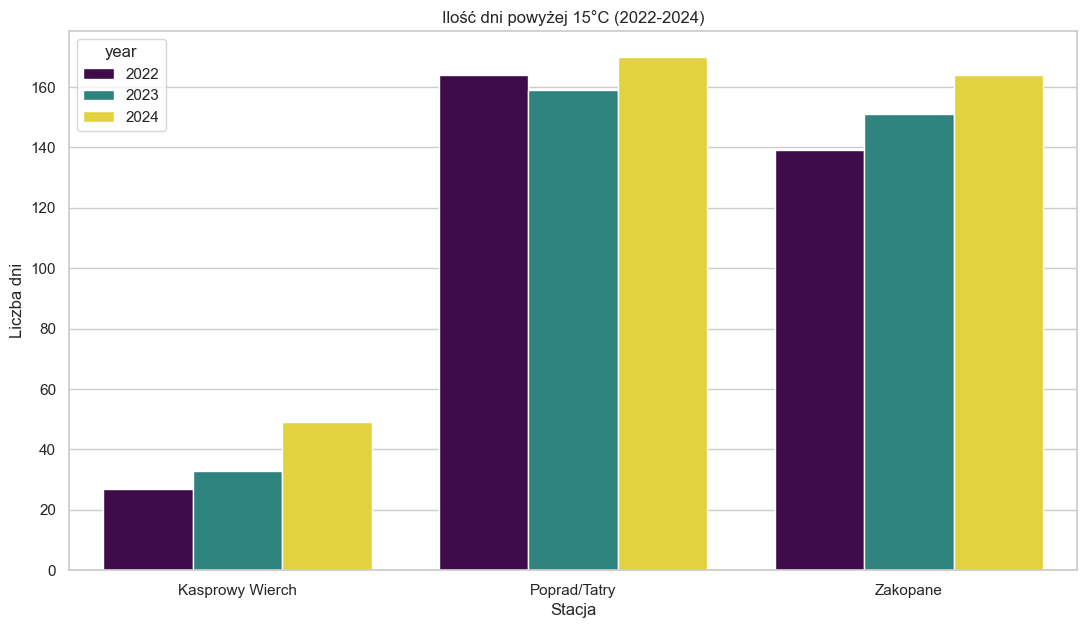

In [41]:
filtered_df = df[(df["max_temp"] > 15) & (df["date"].dt.year.isin([2022, 2023, 2024]))]
filtered_df['year'] = filtered_df['date'].dt.year
summary = filtered_df.groupby(["station_name", "year"])["max_temp"].count().reset_index()
summary.rename(columns={'max_temp': 'Liczba dni'}, inplace=True)

plt.figure(figsize=(13, 7))
sns.barplot(
    data=summary,
    x='station_name',
    y='Liczba dni',
    hue='year',
    palette='viridis',
    errorbar=None
)

plt.title("Ilość dni powyżej 15°C (2022-2024)")
plt.xlabel("Stacja");

**Wnioski**
- Liczba dni z temperaturą >15°C rośnie w większości stacji (2022–2024) → sygnał ocieplenia.
- Poprad – niewielkie odchylenie od trendu (2022 cieplejszy niż 2023)
- Kasprowy Wierch – zdecydowanie mniej dni >15°C → wpływ wysokości nad poziomem morza.
- Zmiany klimatyczne różnią się między stacjami → lokalne czynniki mają duże znaczenie.